In [3]:
import os
import sys
sys.path.append("../")
from dataset import *

In [8]:
dataset, loader = build_split_unlabeled_dataloader(
    data_root="../Data",
    roots=[1],
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    num_workers=32,
    pin_memory=True,
    return_metadata=True,
)


=== Scanning ../Data/Train Unlabeled 01 ===
[Folder] ../Data/Train Unlabeled 01/2026-02-03 -> 6214 image(s)
[Folder] ../Data/Train Unlabeled 01/2026-02-04 -> 3285 image(s)
[Folder] ../Data/Train Unlabeled 01/2026-02-05 -> 1758 image(s)
[Root Summary] ../Data/Train Unlabeled 01 -> 11257 original image(s)

[Grand Summary] Total original images indexed: 11257
[Grand Summary] Total split samples indexed: 22514


In [13]:
images, meta = next(iter(loader))
print(images.shape)   # [B, 3, 224, 224]
print(meta)

torch.Size([16, 3, 224, 224])
{'path': ['../Data/Train Unlabeled 01/2026-02-04/20260204_003703_050621_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_111412_005575_combined.jpg', '../Data/Train Unlabeled 01/2026-02-04/20260204_213654_009088_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_111215_005403_combined.jpg', '../Data/Train Unlabeled 01/2026-02-04/20260204_234157_018588_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_112238_006322_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_200400_031215_combined.jpg', '../Data/Train Unlabeled 01/2026-02-04/20260204_234402_018748_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_110037_004430_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_204505_033705_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_112507_006542_combined.jpg', '../Data/Train Unlabeled 01/2026-02-03/20260203_170715_019720_combined.jpg', '../Data/Train Unlabeled 01/2026-02-

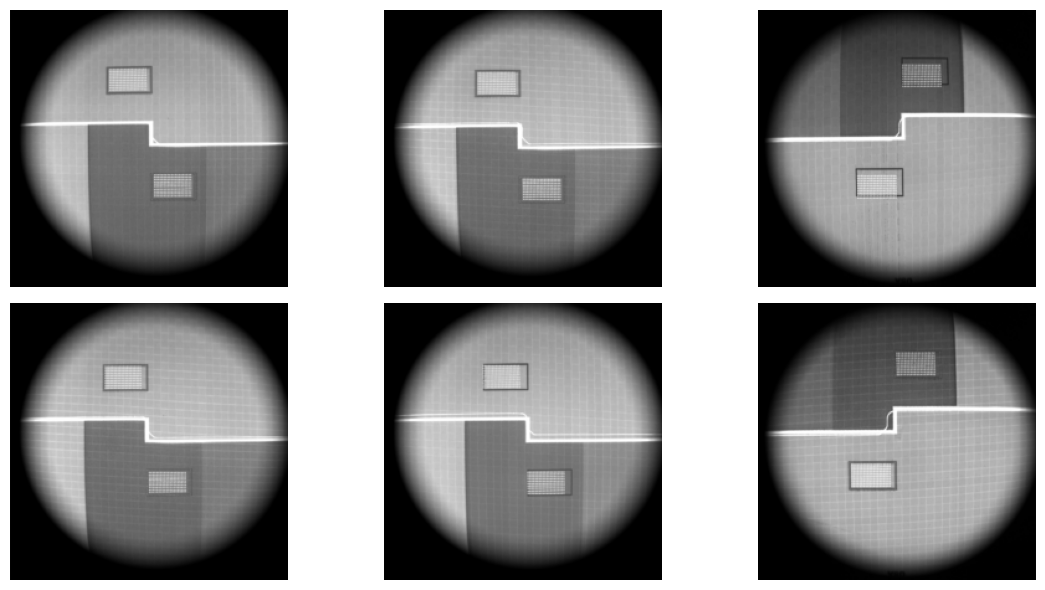

In [14]:
from matplotlib import pyplot as plt

B = images.shape[0]
num_show = min(6, B)

plt.figure(figsize=(12, 6))

for i in range(num_show):
    img = images[i].permute(1, 2, 0).cpu().numpy()  # [H, W, C]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # optional title
    if isinstance(meta, list) or isinstance(meta, tuple):
        plt.title(f"{meta[i]['date']} | {meta[i]['side']}")

plt.tight_layout()
plt.show()

## Check fast data processor

In [17]:
from fast_data_process import *
# dataset = SavedTensorDataset("Data/Processed_unlabeled/X_unlabeled_root_01_2026-02-03.pt")
# loader = DataLoader(dataset, batch_size=32, shuffle=True)

import os
import glob
import bisect
import torch
from torch.utils.data import Dataset, DataLoader


class ChunkedTensorDataset(Dataset):
    """
    Dataset for chunked .pt files, where each file contains a tensor
    of shape [N, 3, 224, 224].

    Efficient behavior:
    - only one chunk is loaded at a time
    - global indexing is mapped to (chunk_id, local_idx)
    """

    def __init__(self, data_dir, pattern="*.pt", transform=None):
        self.data_dir = data_dir
        self.transform = transform

        self.chunk_files = sorted(glob.glob(os.path.join(data_dir, pattern)))
        if len(self.chunk_files) == 0:
            raise FileNotFoundError(f"No .pt files found in {data_dir} matching {pattern}")

        self.chunk_lengths = []
        self.cumulative_sizes = []

        total = 0
        for f in self.chunk_files:
            x = torch.load(f, map_location="cpu")
            if not isinstance(x, torch.Tensor):
                raise TypeError(f"{f} does not contain a tensor")
            n = x.shape[0]
            self.chunk_lengths.append(n)
            total += n
            self.cumulative_sizes.append(total)

        self.total_len = total

        self._cached_chunk_idx = None
        self._cached_chunk = None

        print(f"[Dataset] Found {len(self.chunk_files)} chunk files")
        print(f"[Dataset] Total samples: {self.total_len}")

    def __len__(self):
        return self.total_len

    def _load_chunk(self, chunk_idx):
        if self._cached_chunk_idx != chunk_idx:
            self._cached_chunk = torch.load(
                self.chunk_files[chunk_idx],
                map_location="cpu"
            )
            self._cached_chunk_idx = chunk_idx
        return self._cached_chunk

    def __getitem__(self, idx):
        if idx < 0 or idx >= self.total_len:
            raise IndexError(f"Index {idx} out of range for dataset of size {self.total_len}")

        chunk_idx = bisect.bisect_right(self.cumulative_sizes, idx)
        prev_cum = 0 if chunk_idx == 0 else self.cumulative_sizes[chunk_idx - 1]
        local_idx = idx - prev_cum

        chunk = self._load_chunk(chunk_idx)
        x = chunk[local_idx]

        if self.transform is not None:
            x = self.transform(x)

        return x

In [19]:
def build_dataloader(
    data_dir,
    pattern="*.pt",
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True,
):
    dataset = ChunkedTensorDataset(data_dir=data_dir, pattern=pattern)

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=drop_last,
        persistent_workers=(persistent_workers and num_workers > 0),
    )
    return dataset, loader

In [21]:
dataset, loader = build_dataloader(
    data_dir="../Data/Processed_unlabeled",
    pattern="X_unlabeled_root_01_*.pt",   # only root 1
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

[Dataset] Found 57 chunk files
[Dataset] Total samples: 14476


In [23]:
for batch in loader:
    print(batch.shape)   # [B, 3, 224, 224]
    break

RuntimeError: DataLoader worker (pid(s) 2402902, 2402974, 2403094) exited unexpectedly